![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_3/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Recomendando Música

El objetivo de este caso-taller es construir un sistema de recomendación de Música utilizando los datos de [Last.fm](https://www.last.fm/) provistos  abiertamente por [grouplens](https://grouplens.org/about/what-is-grouplens/) para: **"avanzar la teoría y la práctica de la computación social mediante la construcción y la comprensión de sistemas *(de recomendación)* utilizados por personas reales".**

Los datos contienen información sobre artistas, usuarios, y las veces que estos escucharon sus canciones. Las bases se encuentran en los `Archivos de Laboratorio` en la carpeta `data`, allí también está disponible un archivo [README](data/readme.txt) que contiene más información sobre las bases.


## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

En la carpeta `data` se encuentran los archivos:

   - `artists.dat`  que contienen el identificador del artista (`id`), nombre (`name`), link a la página del artista en last.fm (`url`), y link a la imagen del usuario (`pictureURL`), vale aclarar que varios de estos links están rotos.
   - `user_artists.dat`  que contiene identificador del usuario (`userID`), nombre del artista que escuchó (`artistID`), y las veces que los escuchó (`weight`).

Cargue estos datos en su *cuaderno*:

   1. Para la base de artistas seleccione las columnas de identificador de artista (`id`) y nombre (`name`). Renombre estas columnas para poder hacer la unión con la base `user_artists.dat`.
   2. Para la base de usuarios y artistas, renombre las columnas de forma tal que se mantenga la consistencia para unir con la base anterior, y renombre la columna `weight` a `nro_reproducciones`.
   3. Una estas bases.
   

In [1]:
# Configuración del entorno
import pandas as pd
import numpy as np
import math
from sklearn.metrics.pairwise import cosine_similarity
!pip install apyori
from apyori import apriori
import matplotlib.pyplot as plt

# Clonamos el repositorio
!git clone https://github.com/camto-24/Taller-3-Aprendizaje-no-supervisado.git

# Entramos a la carpeta
%cd Taller-3-Aprendizaje-no-supervisado

# Verificamos
!ls

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5976 sha256=6cb3e4120800b15e6c3c3db9dfa3404ac33bf3f4acdda21c0895bd68813b90e5
  Stored in directory: c:\users\libia\appdata\local\pip\cache\wheels\7f\49\e3\42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori
c:\Users\LIBIA\Documents\Zaira\MEcA\4. semestre\3. Aprendizaje no supervisado\Talleres\Taller-3-Aprendizaje-no-supervisado\Taller-3-Aprendizaje-no-supervisado


Cloning into 'Taller-3-Aprendizaje-no-supervisado'...
"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
!ls

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [3]:
# Cargamos información de artistas
artistas = pd.read_csv('./data/artists.dat', sep='\t', encoding='latin-1')
artistas.head()
artistas.info()
artistas.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17632 entries, 0 to 17631
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          17632 non-null  int64 
 1   name        17632 non-null  object
 2   url         17632 non-null  object
 3   pictureURL  17188 non-null  object
dtypes: int64(1), object(3)
memory usage: 551.1+ KB


Index(['id', 'name', 'url', 'pictureURL'], dtype='object')

In [4]:
# Cargamos información música
musica = pd.read_csv('./data/user_artists.dat', sep='\t', encoding='latin-1')
musica.head()
musica.info()
musica.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   userID    92834 non-null  int64
 1   artistID  92834 non-null  int64
 2   weight    92834 non-null  int64
dtypes: int64(3)
memory usage: 2.1 MB


Index(['userID', 'artistID', 'weight'], dtype='object')

In [5]:
# Estandarización de los nombres de las variables
artistas = artistas.rename(columns={'id': 'artistID','name': 'artist_name'})
artistas.head()

#Merge de las dos bases
base_total = pd.merge(musica,
    artistas,
    on='artistID',
    how='left'
)

base_total

,userID,artistID,weight,artist_name,url,pictureURL
0,2,51,13883,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,11690,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,11351,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,10300,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,8983,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...
...,...,...,...,...,...,...
92829,2100,18726,337,Nyktalgia,http://www.last.fm/music/Nyktalgia,http://userserve-ak.last.fm/serve/252/49060167...
92830,2100,18727,297,Atsakau niekadA,http://www.last.fm/music/Atsakau++niekadA,http://userserve-ak.last.fm/serve/252/29862435...
92831,2100,18728,281,Domantas Razauskas,http://www.last.fm/music/Domantas+Razauskas,http://userserve-ak.last.fm/serve/252/165556.jpg
92832,2100,18729,280,Atalyja,http://www.last.fm/music/Atalyja,http://userserve-ak.last.fm/serve/252/98093.jpg


En primer lugar se cargaron los archivos artists.dat y user_artists.dat, los cuales contienen la información de los artistas y las interacciones entre usuarios y artistas, respectivamente. Para ello, se utilizó la librería pandas, especificando que los archivos se encuentran separados por tabulaciones y utilizando una codificación adecuada para evitar problemas con caracteres especiales en los nombres de los artistas.

Seguido a esto, se realizó una revisión de la estructura de ambas bases de datos con el fin de identificar las variables relevantes para el análisis. Se observó que el identificador del artista tenía nombres distintos en cada tabla, por lo que fue necesario estandarizar los nombres de las variables. En particular, el identificador fue renombrado como `artistID` y el nombre del artista como artist_name, facilitando así la consistencia entre las bases y mejorando la claridad de la información.

Finalmente, se realizó la unión de las tablas mediante un merge usando `artistID` como llave común. Como resultado, se obtuvo una base que integra tanto las interacciones de los usuarios con los artistas como la información descriptiva de estos últimos.

### 2. Análisis preliminar.

En esta sección exploraremos la base. Para ello responda las siguientes preguntas.

#### 2.1 ¿Cuantos usuarios y artistas hay en la base?


In [6]:
#Fase exploratoria: número de usuarios y artistas
n_usuarios = base_total['userID'].nunique()
n_artistas = base_total['artistID'].nunique()

print("Número de usuarios:", n_usuarios)
print("Número de artistas:", n_artistas)

Número de usuarios: 1892
Número de artistas: 17632


Con el fin de explorar la estructura general de la base, se calculó el número de usuarios y artistas únicos presentes en la base consolidada. Para esto, se contaron los valores distintos de las variables `userID` y `artistID`.





#### 2.2 ¿Cuál es la distribución de probabilidad del consumo por artista? (haga el calculo sin ponderar y ponderando por el numero de reproducciones) ¿Qué podemos inferir a partir de la comparación de ambas?

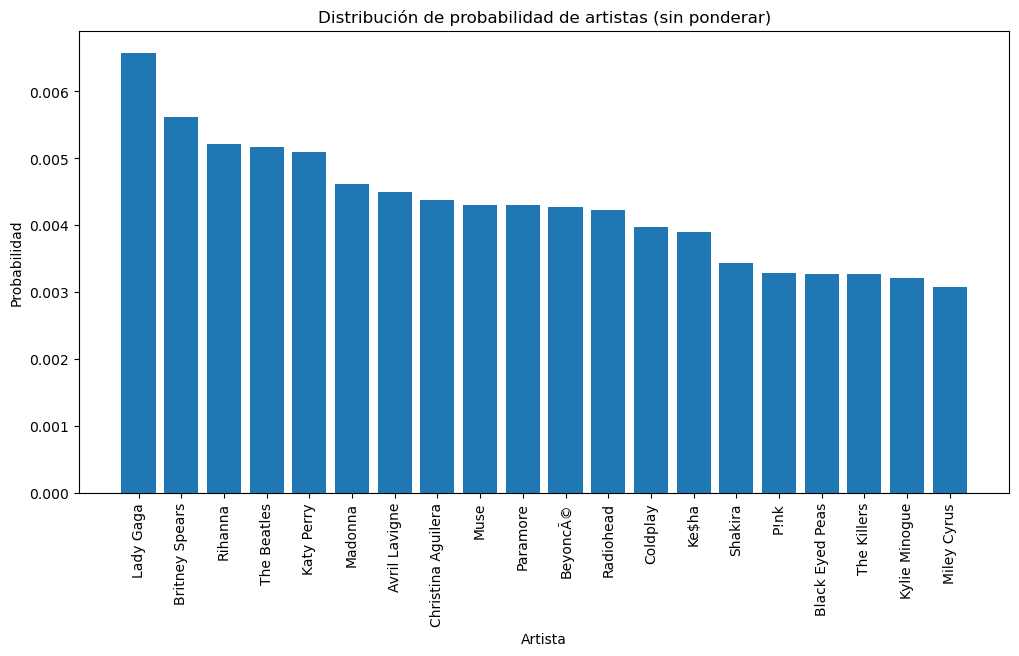

In [7]:
# Distribución de probabilidad del consumo por artista

# Sin ponderar
dist_sin = (
    base_total['artist_name']
    .value_counts(normalize=True)
    .reset_index()
)

dist_sin.columns = ['artist_name', 'probability']
dist_sin.head()

# Top 20 artistas más frecuentes
top_artistas_sin = dist_sin.head(20)

top_sin = dist_sin.sort_values(
    by='probability',
    ascending=False
).head(20)

# Gráfico
plt.figure(figsize=(12,6))

plt.bar(
    top_sin['artist_name'],
    top_sin['probability']
)

plt.xticks(rotation=90)

plt.title('Distribución de probabilidad de artistas (sin ponderar)')
plt.xlabel('Artista')
plt.ylabel('Probabilidad')

plt.show()


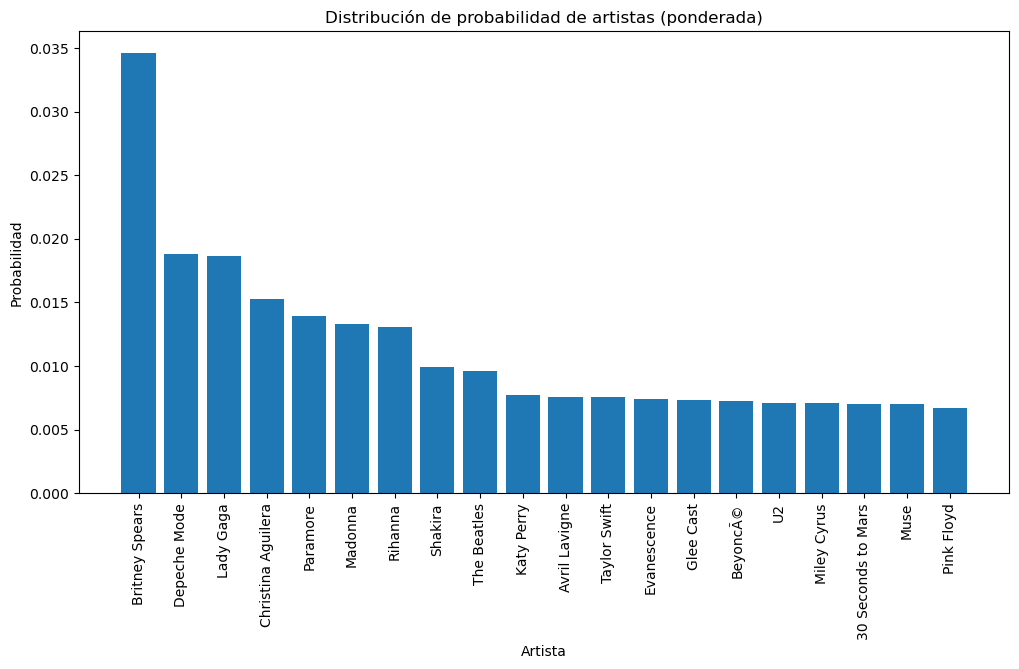

In [8]:
# Distribución de probabilidad del consumo por artista

# Ponderado
dist_con = (base_total.groupby('artist_name')['weight'].sum())

# Convertir en distribución de probabilidad
dist_proba_con = (dist_con / dist_con.sum()).reset_index()

dist_proba_con.columns = ['artist_name', 'probability']

dist_proba_con.head()

# Top 20 artistas consumo ponderado
top_ponderado = dist_proba_con.sort_values(by='probability',ascending=False).head(20)

# Gráfico
plt.figure(figsize=(12,6))

plt.bar(
    top_ponderado['artist_name'],
    top_ponderado['probability']
)

plt.xticks(rotation=90)

plt.title('Distribución de probabilidad de artistas (ponderada)')
plt.xlabel('Artista')
plt.ylabel('Probabilidad')

plt.show()


Al comparar las distribuciones de probabilidad sin ponderar y ponderada, se observan diferencias importantes en la forma en que ciertos artistas concentran la actividad de los usuarios. En la distribución sin ponderar, artistas como *Lady Gaga*, *Britney Spears* y *Rihanna* aparecen con alta frecuencia dentro de las interacciones registradas, lo que sugiere una amplia presencia entre los usuarios de la plataforma.

Sin embargo, al incorporar el número de reproducciones mediante la distribución ponderada, *Britney Spears* pasa a concentrar una proporción significativamente mayor del consumo total, mientras que aparecen artistas como Depeche Mode y The Beatles, que no destacaban tanto en la distribución anterior.

Esto indica que algunos artistas pueden tener una gran cantidad de usuarios oyentes, pero no necesariamente altos niveles de reproducción, mientras que otros presentan audiencias más intensivas en términos de consumo musical. En conjunto, ambas aproximaciones permiten distinguir entre popularidad por alcance e intensidad real de escucha, proporcionando un mayor entendimiento del consumo dentro de la plataforma.


#### 2.3 Para el usuario 8 (`userID==8`) ¿cuál es la distribución de reproducción de artistas basado en el número de reproducciones relativas?. Presente sus resultados usando tablas y/o gráficas. ¿Encuentra algún patrón en los artistas que escucha y las veces que reproduce? ¿Podemos decir algo de sus preferencias?


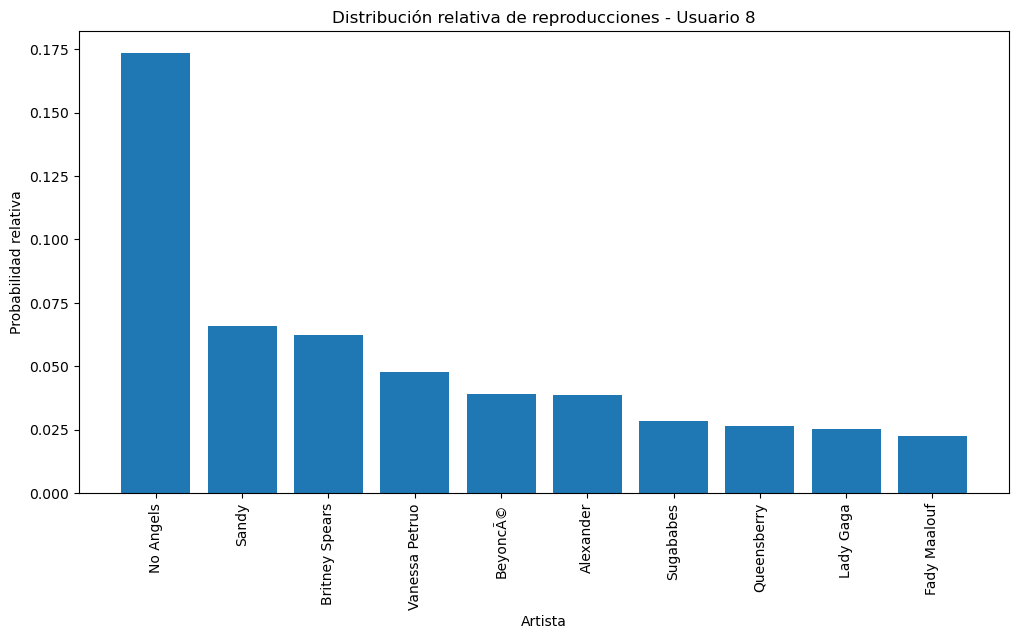

In [9]:
# Filtro para el usuario
user8 = base_total[base_total['userID'] == 8]

# Consumo total del usuario
total_user8 = user8['weight'].sum()

# Distribución relativa por artista
user8_dist = (
    user8.groupby('artist_name')['weight']
    .sum()
    .sort_values(ascending=False)
    / total_user8
).reset_index()

user8_dist.columns = ['artist_name', 'relative_probability']

user8_dist.head()

# Top 10 artistas del usuario
top_user8 = user8_dist.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_user8['artist_name'],
    top_user8['relative_probability']
)

plt.xticks(rotation=90)

plt.title('Distribución relativa de reproducciones - Usuario 8')
plt.xlabel('Artista')
plt.ylabel('Probabilidad relativa')

plt.show()

Con el fin de analizar las preferencias individuales del usuario 8, se calculó la distribución relativa de reproducciones por artista utilizando el número de reproducciones asociado a cada interacción.

Para ello, se estimó la proporción que representa cada artista sobre el total de reproducciones del usuario. La visualización obtenida permite identificar que las artistas *No Angels* son las más reproducidas, seguidas por *Sandy* y *Britney Spears*. Este análisis proporciona una aproximación inicial a las preferencias musicales del usuario y resulta fundamental para la construcción de sistemas de recomendación personalizados.

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones ***nuevas y relevantes*** para el usuario 8 (`userID==8`). Para ello vamos a generar distintos sistemas de recomendación y comparar las recomendaciones generadas.

#### 3.1. Filtrado colaborativo sencillo: promedios simples.

Usando el promedio simple basado en el número de usuarios que escucha un artista (sin considerar el número de veces que estos usuarios reproducen al artista) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones.

In [10]:
# Número de usuarios por artista
populares = (
    base_total.groupby('artist_name')['userID']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

populares.columns = ['artist_name', 'n_usuarios']

# Artistas ya escuchados por usuario 8
escuchados = user8['artist_name'].unique()

# Filtrar
recomendaciones = populares[
    ~populares['artist_name'].isin(escuchados)
].head(10)

recomendaciones

,artist_name,n_usuarios
3,The Beatles,480
5,Madonna,429
6,Avril Lavigne,417
8,Muse,400
9,Paramore,399
11,Radiohead,393
12,Coldplay,369
13,Ke$ha,362
14,Shakira,319
16,The Killers,304


Se construyó un sistema de recomendación basado en popularidad simple. Para ello, se agrupó la base de datos por artista y se calculó el número de usuarios únicos que escuchan cada uno. Lo que permitió identificar qué artistas son más populares en la muestra. Posteriormente, se identificaron los artistas ya escuchados por el usuario 8 y se excluyeron del ranking. Finalmente, se seleccionaron los 10 artistas con mayor número de oyentes que el usuario aún no ha escuchado.

Las recomendaciones obtenidas corresponden a artistas muy populares como The Beatles, Madonna y Coldplay. Este resultado es esperado, ya que el criterio utilizado favorece artistas con mayor alcance en la población, independientemente de la intensidad con la que son escuchados.

El método de promedios simples es fácil de implementar y permite generar recomendaciones rápidamente. Sin embargo, presenta limitaciones importantes, ya que no considera qué tan intensamente los usuarios consumen a cada artista, ni las preferencias específicas del usuario objetivo.

#### 3.2.  Filtrado colaborativo sencillo: promedios ponderados.

Usando el promedio ponderado basado en el número de usuarios que escucha un artista  y ponderando  por el número de veces que estos usuarios reproducen al artista (`nro_reproducciones`) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.


In [11]:
# Asegurarnos de tener el nombre correcto de la variable
base_total = base_total.rename(columns={'weight': 'nro_reproducciones'})

# 1. Calcular popularidad ponderada (suma de reproducciones por artista)
ponderado = (
    base_total.groupby('artist_name')['nro_reproducciones']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

ponderado.columns = ['artist_name', 'total_reproducciones']

# 2. Identificar artistas ya escuchados por el usuario 8
escuchados = base_total[
    base_total['userID'] == 8
]['artist_name'].unique()

# 3. Filtrar artistas NO escuchados (recomendaciones)
recomend_ponderado = ponderado[
    ~ponderado['artist_name'].isin(escuchados)
].head(10)

# 4. Mostrar tabla de recomendaciones
recomend_ponderado

,artist_name,total_reproducciones
1,Depeche Mode,1301308
4,Paramore,963449
5,Madonna,921198
7,Shakira,688529
8,The Beatles,662116
10,Avril Lavigne,525844
12,Evanescence,513476
13,Glee Cast,506453
15,U2,493024
16,Miley Cyrus,489065


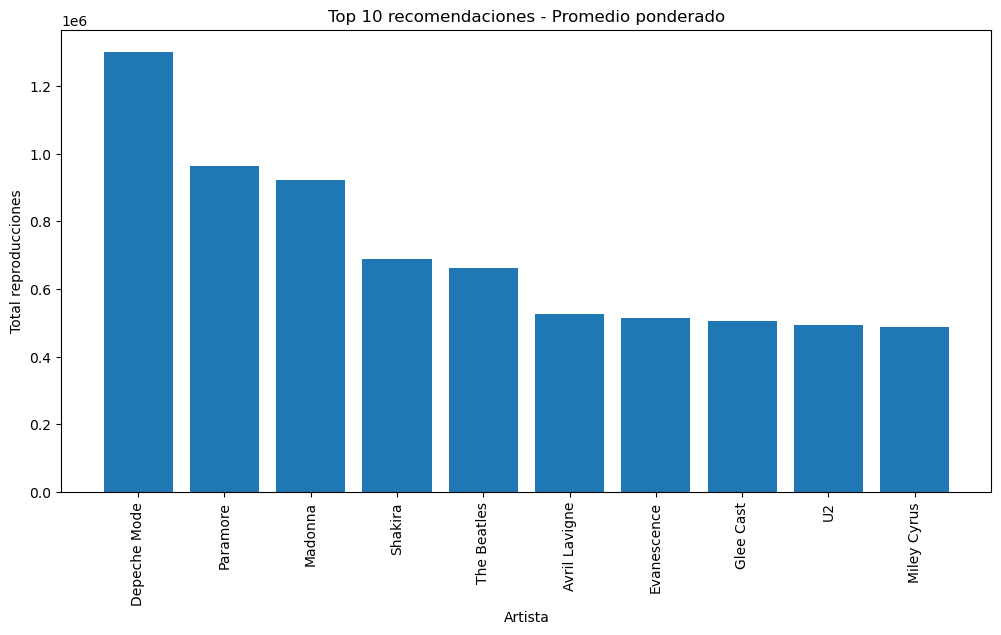

In [12]:
# Gráfico

plt.figure(figsize=(12,6))

plt.bar(
    recomend_ponderado['artist_name'],
    recomend_ponderado['total_reproducciones']
)

plt.xticks(rotation=90)

plt.title('Top 10 recomendaciones - Promedio ponderado')
plt.xlabel('Artista')
plt.ylabel('Total reproducciones')

plt.show()

Para generar las recomendaciones se utilizó un enfoque de filtrado colaborativo basado en promedios ponderados. En particular, se calculó la popularidad de cada artista como la suma total de reproducciones (nro_reproducciones) realizadas por todos los usuarios. Este enfoque permite capturar no solo cuántos usuarios escuchan a un artista, sino también la intensidad del consumo, dando mayor peso a aquellos artistas que son reproducidos con mayor frecuencia. Posteriormente, se identificaron los artistas que ya habían sido escuchados por el usuario 8 y se excluyeron del análisis, con el objetivo de generar recomendaciones nuevas. A partir de esto, se seleccionaron los 10 artistas con mayor número total de reproducciones

A diferencia del enfoque anterior, las recomendaciones incluyen artistas como Depeche Mode, Evanescence y Glee Cast, que no necesariamente eran los más populares en número de usuarios, pero sí presentan altos niveles de reproducción. Esto indica que el modelo ahora favorece artistas con audiencias más intensas o fieles. Por ejemplo, un artista puede tener menos oyentes, pero si estos lo escuchan muchas veces, sube en el ranking.

El enfoque ponderado representa una mejora frente al promedio simple, ya que incorpora información adicional sobre el comportamiento de los usuarios. Esto permite generar recomendaciones potencialmente más relevantes.

#### 3.3.  Filtrado colaborativo sencillo: similitud de coseno.

Usando el promedio ponderado de reproducciones genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario. Para generar los pesos utilice la distancia de coseno. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.

In [13]:
# Librerias

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# Matriz usuario-artista
matriz = base_total.pivot_table(
    index='userID',
    columns='artist_name',
    values='nro_reproducciones',
    fill_value=0
)

# Similitud de coseno entre usuarios
similitud = cosine_similarity(matriz)

similitud_df = pd.DataFrame(
    similitud,
    index=matriz.index,
    columns=matriz.index
)

# Similitud del usuario 8 con los demás
sim_user8 = similitud_df.loc[8].drop(8)

# Promedio ponderado
scores = np.dot(sim_user8.values, matriz.loc[sim_user8.index])
scores = scores / sim_user8.sum()

scores = pd.Series(scores, index=matriz.columns)

# Eliminar artistas ya escuchados por el usuario 8
escuchados = matriz.loc[8]
escuchados = escuchados[escuchados > 0].index

recomendaciones = scores.drop(escuchados)

# Top 10 recomendaciones
top10_coseno = recomendaciones.sort_values(ascending=False).head(10)

top10_coseno.reset_index().rename(
    columns={'index': 'artist_name', 0: 'score'}
)

,artist_name,score
0,Madonna,1398.495123
1,Kylie Minogue,853.912617
2,Shakira,764.191339
3,Miley Cyrus,758.443202
4,Ke$ha,727.190875
5,Avril Lavigne,647.448373
6,Paramore,541.648483
7,Glee Cast,419.659579
8,Black Eyed Peas,328.901913
9,Ashley Tisdale,314.160848


Para generar las recomendaciones se implementó un sistema de filtrado colaborativo basado en similitud de coseno. Primero, se construyó una matriz usuario-artista utilizando el número de reproducciones (nro_reproducciones) como medida de consumo. Posteriormente, se calculó la similitud entre usuarios y se identificaron aquellos con patrones musicales más cercanos al usuario 8. Con esta información, se estimó un puntaje ponderado para cada artista y se excluyeron los artistas ya escuchados previamente por el usuario.

Los resultados muestran que artistas como Madonna, Kylie Minogue y Shakira presentan los mayores puntajes de recomendación, lo que indica que son altamente consumidos por usuarios con gustos similares al usuario 8. También aparecen artistas pop como Miley Cyrus Avril Lavigne, lo que sugiere una preferencia marcada por este género musical. Esto evidencia que el modelo logra identificar patrones de consumo coherentes con las preferencias del usuario.

En comparación con el método de promedios ponderados del punto anterior, este enfoque genera recomendaciones más personalizadas, ya que no depende únicamente de la popularidad global de los artistas. La similitud de coseno permite incorporar información sobre usuarios con comportamientos similares, mejorando la relevancia de las recomendaciones. En conclusión, este método ofrece resultados más ajustados a los gustos del usuario y representa una aproximación más robusta para sistemas de recomendación musicales.

#### 3.4.  Filtrado colaborativo usando SVD


Usando la descomposición en valores singulares (SVD) genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores.


In [14]:
# Librerias

from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np

# Matriz usuario-artista
matriz = base_total.pivot_table(
    index='userID',
    columns='artist_name',
    values='nro_reproducciones',
    fill_value=0
)

# Aplicar SVD
svd = TruncatedSVD(
    n_components=20,
    random_state=42
)

matriz_svd = svd.fit_transform(matriz)

# Reconstrucción aproximada de la matriz
matriz_reconstruida = np.dot(
    matriz_svd,
    svd.components_
)

# Convertimos nuevamente a DataFrame
predicciones = pd.DataFrame(
    matriz_reconstruida,
    index=matriz.index,
    columns=matriz.columns
)

# Predicciones para el usuario 8
pred_user8 = predicciones.loc[8]

# Eliminar artistas ya escuchados
escuchados = matriz.loc[8]
escuchados = escuchados[escuchados > 0].index

recomendaciones_svd = pred_user8.drop(escuchados)

# Top 10 recomendaciones
top10_svd = recomendaciones_svd.sort_values(
    ascending=False
).head(10)

# Mostrar resultados
top10_svd.reset_index().rename(
    columns={'index': 'artist_name', 8: 'score_predicho'}
)

,artist_name,score_predicho
0,Miley Cyrus,392.699607
1,Madonna,356.297565
2,Avril Lavigne,250.860368
3,Ke$ha,213.240358
4,Kylie Minogue,175.908711
5,Shakira,153.781995
6,Eminem,123.179162
7,Black Eyed Peas,103.773414
8,Hilary Duff,87.951213
9,Leona Lewis,86.851194


Para este punto se implementó un sistema de recomendación usando Descomposición en Valores Singulares (SVD). Se construyó una matriz usuario-artista con el número de reproducciones (`nro_reproducciones`) y posteriormente se aplicó SVD para reducir la dimensionalidad y capturar patrones latentes de consumo musical. Finalmente, se generaron predicciones para el usuario 8 y se seleccionaron los 10 artistas con mayor puntaje no escuchados previamente.

Los resultados muestran que artistas como Miley Cyrus, Madonna y Avril Lavigne presentan los mayores puntajes de recomendación, seguidos por Ke$ha, Kylie Minogue y Shakira. Esto sugiere que el modelo identifica preferencias asociadas principalmente al género pop, estos resultados son consistentes con los patrones de escucha de los análisis anteriores.

En comparación con los métodos anteriores, SVD genera recomendaciones más personalizadas al identificar relaciones ocultas entre usuarios y artistas. A diferencia de los modelos basados únicamente en popularidad o similitud directa, este enfoque logra capturar mejor la estructura de preferencias musicales y producir recomendaciones más robustas.


#### 3.5.  Filtrado colaborativo usando Análisis de Canasta de Compra

Usando  el algoritmo `Apriori` genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores. Esto puede tomar mucho tiempo, sea cuidadoso al elegir los hiper-parámetors del modelo, utilice los resultados de las estadísticas descriptivas para elegir sus hier-parámetros, y genere solo reglas con 2 elementos. (Puede también aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


Reglas encontradas: 455
(864, 5)


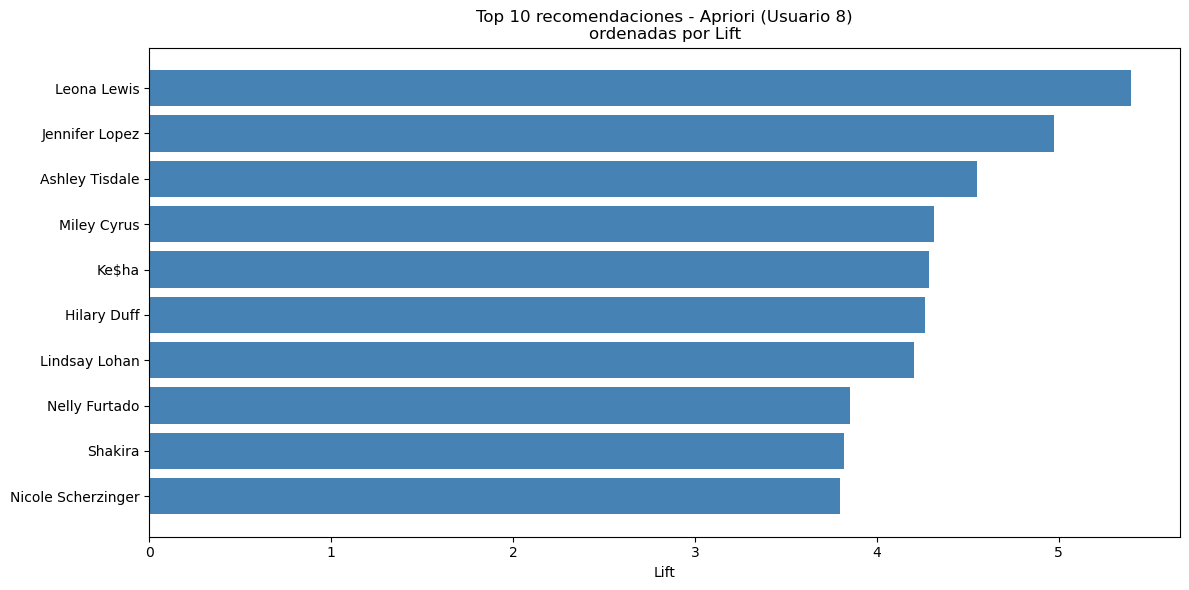

In [16]:
from apyori import apriori
import pandas as pd

# Creación de Canastas, donde cada usuario es una transaccion con los artistas que escuchó
canastas = (
    base_total
    .groupby('userID')['artist_name']
    .apply(list)
    .tolist()
)

# Hiperparámetros de acuerdo a los resultados del 2.2 (estadísticas descriptivas)
reglas_raw = list(apriori(
    canastas,
    min_support=0.05,
    min_confidence=0.20,
    min_lift=1.0,
    max_length=2
))
print(f"Reglas encontradas: {len(reglas_raw)}")

# Resultados
registros = []
for regla in reglas_raw:
    items = list(regla.items)
    if len(items) < 2:
        continue
    for stat in regla.ordered_statistics:
        antecedente = list(stat.items_base)
        consecuente = list(stat.items_add)
        if len(antecedente) == 1 and len(consecuente) == 1:
            registros.append({
                'antecedente': antecedente[0],
                'consecuente': consecuente[0],
                'soporte':     regla.support,
                'confianza':   stat.confidence,
                'lift':        stat.lift
            })

reglas_df = pd.DataFrame(registros)
print(reglas_df.shape)
reglas_df.head()

# Generar recomendaciones para el usuario 8

# Artistas que ya escucha el usuario
escuchados_u8 = set(
    base_total[base_total['userID'] == 8]['artist_name'].unique()
)

# Según los escuchados historicos de artistas pero no ha sido escuchado aún
recom_apriori = (
    reglas_df[
        reglas_df['antecedente'].isin(escuchados_u8) &
        ~reglas_df['consecuente'].isin(escuchados_u8)
    ]
    .sort_values(by='lift', ascending=False)   # ordenar por lift
    .drop_duplicates(subset='consecuente')      # un registro por artista
    .head(10)
    [['consecuente', 'antecedente', 'soporte', 'confianza', 'lift']]
    .reset_index(drop=True)
)

recom_apriori.columns = [
    'Artista recomendado', 'Basado en', 'Soporte', 'Confianza', 'Lift'
]

recom_apriori

# Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(
    recom_apriori['Artista recomendado'],
    recom_apriori['Lift'],
    color='steelblue'
)
plt.xlabel('Lift')
plt.title('Top 10 recomendaciones - Apriori (Usuario 8)\nordenadas por Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Para construir el sistema de recomendación basado en reglas de asociación se utilizó el algoritmo Apriori, adaptando el paradigma del análisis de canasta de compra al dominio musical: cada usuario representa una "transacción" y los artistas que escuchó son los "productos" de esa canasta.

**Construcción de las canastas.** Se agrupó la base por `userID` y se recopilaron los nombres de artistas en listas, obteniendo una transacción por usuario.

**Selección de hiperparámetros.** A partir de los resultados del análisis descriptivo (puntos 2.2 y 2.3) se observó que la mayoría de artistas aparecen en una fracción pequeña de usuarios. Con 1 892 usuarios, se fijó un `min_support = 0.05`, lo que exige que una asociación aparezca en al menos 95 usuarios, garantizando estabilidad estadística sin eliminar artistas relevantes. Se estableció `min_confidence = 0.20` para conservar reglas con un nivel mínimo de predictibilidad, y `min_lift > 1.0` para asegurar que las asociaciones superen lo esperado por azar. Finalmente, se limitó `max_length = 2` para generar exclusivamente reglas de dos elementos, reduciendo significativamente el tiempo de cómputo y facilitando la interpretación.

**Generación de recomendaciones.** Se filtraron las reglas cuyo antecedente corresponde a artistas ya escuchados por el usuario 8, y cuyo consecuente es un artista nuevo. Las recomendaciones se ordenaron por **lift**, ya que esta métrica refleja la fuerza real de la asociación más allá de la popularidad marginal de cada artista. Se seleccionaron los 10 artistas con mayor lift.

**Análisis de resultados.** Las recomendaciones generadas por Apriori son coherentes con el perfil del usuario 8, identificado en el punto 2.3 como aficionado al pop y artistas femeninas. La métrica de lift confirma que estas asociaciones son estadísticamente significativas, es decir, los usuarios que escuchan los mismos artistas que el usuario 8 tienen una probabilidad notablemente mayor de escuchar a los artistas recomendados.

**Comparación con métodos anteriores.** A diferencia de los métodos de popularidad (3.1 y 3.2), Apriori no recomienda simplemente los artistas más escuchados en general, sino aquellos que co-ocurren con artistas específicos del usuario. Respecto a la similitud de coseno (3.3) y SVD (3.4), Apriori opera a nivel de patrones explícitos de co-ocurrencia entre artistas dentro de las canastas de usuarios, lo que lo hace más interpretable: cada recomendación viene acompañada de una regla que la justifica (soporte, confianza y lift). Su principal limitación es la dependencia del umbral de soporte mínimo, que puede excluir artistas de nicho con audiencias pequeñas pero muy leales.

### 4. Recomendaciones generales

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para este usuario? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

#### ¿Qué procedimiento generó las mejores recomendaciones?

A lo largo del taller se implementaron cinco sistemas de recomendación con niveles crecientes de sofisticación. Con base en los resultados obtenidos, en nuestra opinión el algoritmo **Apriori (3.5)** generó las mejores recomendaciones para el usuario 8.

Para sustentar esta conclusión, es útil contrastar los resultados con el perfil musical del usuario. En el punto 2.3 se identificó que el usuario 8 escucha predominantemente artistas pop femeninas: No Angels concentra el 17.5% de sus reproducciones, seguida por Sandy (6.5%), Britney Spears (6.3%), Vanessa Petruo (4.8%) y Beyoncé (3.9%). Este perfil es consistente y marcado: el usuario tiene una preferencia clara por el pop femenino, con artistas de origen latino, europeo y estadounidense.

Los métodos de popularidad simple y ponderada (3.1 y 3.2) presentan la limitación más evidente: recomiendan artistas globalmente populares sin considerar el perfil individual. En el caso ponderado (3.2), las recomendaciones incluyen Depeche Mode, Paramore y The Beatles —artistas que, si bien son muy reproducidos en la plataforma, no guardan afinidad con el perfil pop-femenino del usuario 8. Esto ocurre porque Britney Spears, la artista con mayor consumo ponderado en toda la base (≈3.5% del total, imagen 2.2 ponderada), ya es escuchada por el usuario, y el modelo simplemente continúa con los siguientes artistas más reproducidos globalmente, sin personalización alguna.

En contraste, Apriori (3.5) generó recomendaciones como Leona Lewis, Jennifer Lopez, Ashley Tisdale, Miley Cyrus, Ke$ha, Hilary Duff, Lindsay Lohan, Nelly Furtado, Shakira y Nicole Scherzinger, todas ellas artistas pop femeninas con valores de lift entre 3.8 y 5.3. Estos valores indican que la probabilidad de que un usuario que escucha artistas similares al usuario 8 también escuche estos artistas es entre 3.8 y 5.3 veces mayor de lo que se esperaría por azar. La coherencia de estas recomendaciones con el perfil identificado en 2.3 es notablemente superior a la de cualquier otro método implementado.

La similitud de coseno (3.3) y SVD (3.4) también lograron recomendaciones personalizadas y coherentes (Madonna, Kylie Minogue, Shakira, Miley Cyrus), aprovechando la intensidad de escucha mediante el número de reproducciones. Sin embargo, Apriori supera a estos métodos en interpretabilidad: cada recomendación viene respaldada por una regla explícita con soporte, confianza y lift, lo que permite entender exactamente por qué se sugiere cada artista. Además, los artistas recomendados por Apriori (como Leona Lewis, Ashley Tisdale o Hilary Duff) representan sugerencias de nicho más afinadas al gusto del usuario, mientras que coseno y SVD tienden a incluir artistas de mayor popularidad global.

En conclusión, Apriori ofrece el mejor balance entre personalización, coherencia con el perfil del usuario y justificabilidad de las recomendaciones para este caso particular.

#### ¿Cómo implementaría una evaluación objetiva?

Evaluar un sistema de recomendación de forma objetiva requiere definir métricas que midan si las sugerencias generadas son relevantes para el usuario. A continuación se describe la estrategia de evaluación que se implementaría:

**1. División temporal de los datos (Train/Test split)**
Se dividiría la base `user_artists.dat` en dos conjuntos: las interacciones se dividirían aleatoriamente de forma estratificada por usuario, reservando el 20% de los artistas escuchados por cada usuario como conjunto de prueba. Esto simula el escenario real en el que el sistema debe predecir consumos futuros a partir de un historial parcial. Para el usuario 8, por ejemplo, se ocultarían algunos de sus artistas conocidos (como Sandy o Vanessa Petruo) y se evaluaría si los modelos los recuperan entre sus recomendaciones.

**2. Métricas de evaluación**

- **Precision K**: mide qué proporción de los K artistas recomendados aparecen efectivamente en el conjunto de prueba del usuario. Responde a: *¿cuántas de mis recomendaciones son realmente relevantes?*

$$Precision K = \frac{|\text{Recomendados} \cap \text{Relevantes}|}{K}$$

- **Recall K**: mide qué proporción de los artistas relevantes del conjunto de prueba fueron capturados entre los K recomendados. Responde a: *¿qué tan exhaustivo es el sistema?*

$$Recall K = \frac{|\text{Recomendados} \cap \text{Relevantes}|}{|\text{Relevantes}|}$$

- **NDCG K** *(Normalized Discounted Cumulative Gain)*: penaliza los aciertos que aparecen en posiciones bajas de la lista. Es la métrica más adecuada aquí porque el orden importa: una recomendación relevante en la posición 1 es más valiosa que una en la posición 10.

- **Coverage**: proporción del catálogo total que el sistema es capaz de recomendar. Los métodos de popularidad (3.1 y 3.2) tendrían baja cobertura al concentrarse siempre en los mismos artistas globales, mientras que Apriori podría cubrir artistas de nicho con alta afinidad.

**3. Comparación entre modelos**
Con estas métricas calculadas sobre todos los usuarios (no solo el usuario 8), se construiría una tabla comparativa que promedia los resultados y permite una evaluación objetiva y reproducible de los cinco sistemas. Se esperaría que los métodos de popularidad simple y ponderada obtuvieran los peores resultados en PrecisionK y NDCGK dada su falta de personalización, como evidenciada en las recomendaciones del punto 3.2 con artistas como Depeche Mode o The Beatles, ajenos al perfil del usuario 8, mientras que Apriori, coseno y SVD competirían por los mejores resultados.

**4. Consideraciones adicionales**
Es importante considerar el problema de *cold start*: los métodos basados en similitud de coseno y SVD requieren historial previo del usuario; para usuarios nuevos sin interacciones, los métodos de popularidad (3.1 y 3.2) o Apriori serían más apropiados como punto de partida. Una implementación robusta combinaría ambos enfoques según el nivel de información disponible.